# Valuation of Collectible Cards based on Intrinsic and or Etrinsic Characteristics - (2025-26 AM41PRA) Research Project
**Name:**  Muhammad Faisal Chughtai

**Student ID:** 250129234


---

## Introduction
This methodology represents the sequential architecture of the machine learning pipeline built for asset price forecasting. This architecture is designed to be highly robust, with controlled computational reproducibility, detailed feature engineering from unstructured data, mitigation of temporal data leakage, and development and deployment of the Deep Stacking Ensemble. 


In [27]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

---
## 1. Computational Reproducibility

To ensure the consistency and integrity of the results, strict computational controls are implemented before model initialization, in accordance with reproducibility standards (Pineau et al., 2021).


In [28]:
MASTER_SEED = 42
os.environ['PYTHONHASHSEED'] = str(MASTER_SEED)
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

---
## 2. Data Ingestion & Target Transformation

The methodology sanitizes the dataset immediately after ingestion and then applies a transformation to the dependent variable. As established in the econometric literature (Wooldridge, 2016), the logarithmic transformation $y' = \log_e(1 + y)$ is applied due to severe right skewness in asset prices. This transformation mitigates heteroscedasticity, normalizes the distribution and prevents extreme outliers from overemphasizing large errors during training.


In [ ]:
print("Loading dataset")
print("-" * 50)
df = pd.read_csv("datasets/pokemon_tcg_dataset.csv")

# dropping columns with all missing values and duplicate rows
df = df.dropna(axis=1, how="all").drop_duplicates()

# cleaning and transforming the target variable
df = df.dropna(subset=["market_price"])
df["market_price"] = df["market_price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
df["log_market_price"] = np.log1p(df["market_price"])

Loading dataset
--------------------------------------------------


---
## 3. Feature Engineering

This block includes the precise sequence of feature engineering to extract the latent signals from raw structured and unstructured data. This block covers the following things mentioned below:

- Temporal Parsing (**pd.to_datetime**): To enable the model to capture transaction recency, the dates were converted to numerical values, generating the number of days since the last sale, such as days_since_sold relative to a fixed global anchor.

- Tokenization (**str.split**): Some text fields, such as **full_name**, contain multiple pieces of information. Tokkenization is applied to split these parts into multiple meaningful fields (such as extracted_name and extracted_set).
- Indicator Matrices (**str.contains**): Applies regular expression scanning across unstructured textual data. This technique determines whether specific words or patterns occur in the textual data and generates binary integer vectors based on the results (such as is_holo).
- Custom Vectorization (**.apply**): Iterates a regex-driven mapping function on unstructured text fields to extract useful numerical information (such as attack_count and max_attack_damage) and later converts it into the proper numerical features for machine learning models.
- Ratio Synthesis: This step creates the relationship-based features by dividing one variable by another, such as card_volume_density.
- Feature Pruning (**df.drop**): Feature pruning removes highly correlated historical features (such as last_sold_price) to ensure the model generalizes well to unseen data and to enforce data leakage mitigation (Kaufman et al. (2012)).


In [30]:
print("Feature Engineering")
print("-" * 50)

df["last_sold_date"] = pd.to_datetime(df["last_sold_date"], format='ISO8601', utc=True, errors="coerce")
df = df.dropna(subset=["last_sold_date"]).sort_values("last_sold_date").reset_index(drop=True)

df["last_sold_year"] = df["last_sold_date"].dt.year
df["last_sold_month"] = df["last_sold_date"].dt.month
dataset_anchor_date = pd.to_datetime(df["scraped_at"]).max().tz_localize(None)
df["days_since_sold"] = (dataset_anchor_date - df["last_sold_date"].dt.tz_localize(None)).dt.days

df["attacks"] = df["attacks"].fillna("").astype(str)
df["attack_count"] = df["attacks"].apply(lambda x: 0 if not x.strip() else x.count("|") + 1)
df["hp"] = pd.to_numeric(df["hp"], errors="coerce").fillna(0)

# converting price columns to number
price_cols = ['ph_marketPrice', 'highSalePriceWithShipping', 'lowSalePriceWithShipping', 'quantitySold', 'history_total_sold', 'transactionCount']
for col in price_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Extract name and set from full_name
df['extracted_name'] = df['full_name'].astype(str).str.split(' - ').str[0]
df['extracted_set'] = df['full_name'].astype(str).str.split(' - ').str[-1]
# Extract variant indicators from full_name
df['is_psa_10'] = df['full_name'].str.contains(r'PSA\s*10', case=False, na=False).astype(int)
df['is_psa_9'] = df['full_name'].str.contains(r'PSA\s*9', case=False, na=False).astype(int)
df['is_bgs'] = df['full_name'].str.contains(r'BGS\s*', case=False, na=False).astype(int)
df['is_first_ed'] = df['full_name'].str.contains(r'1st Edition', case=False, na=False).astype(int)
df['is_holo'] = df['full_name'].str.contains(r'Holo', case=False, na=False).astype(int)
df['is_reverse_holo'] = df['full_name'].str.contains(r'Reverse', case=False, na=False).astype(int)
df['has_error'] = df['full_name'].str.contains(r'Error', case=False, na=False).astype(int)

df['full_name_variant'] = df['full_name'].astype(str) + '_' + df['sku_variant'].astype(str)
df['full_name_condition'] = df['full_name'].astype(str) + '_' + df['sku_condition'].astype(str)
df['name_variant'] = df['extracted_name'].astype(str) + '_' + df['sku_variant'].astype(str)
df['set_variant'] = df['extracted_set'].astype(str) + '_' + df['sku_variant'].astype(str)

num_den = df['card_number'].astype(str).str.extract(r'(\d+)\s*/\s*(\d+)')
df['card_number_num'] = pd.to_numeric(num_den[0], errors='coerce').fillna(0)
df['card_number_den'] = pd.to_numeric(num_den[1], errors='coerce').fillna(0)
df['is_secret_rare'] = ((df['card_number_num'] > df['card_number_den']) & (df['card_number_den'] > 0)).astype(int)
df['is_trainer_gallery'] = df['card_number'].astype(str).str.contains(r'TG|GG|SV|SWSH', case=False, na=False).astype(int)
df['is_promo'] = df['rarity'].astype(str).str.contains(r'Promo', case=False, na=False).astype(int)

# parsing TCG gameplay attributes
df['retreat_cost'] = pd.to_numeric(df['retreat'], errors='coerce').fillna(0)
df['has_weakness'] = df['weakness'].notna().astype(int)
df['has_resistance'] = df['resistance'].notna().astype(int)

def parse_attacks_meta(attack_str):
    if not isinstance(attack_str, str) or not attack_str.strip():
        return pd.Series([0, 0.0, 0.0, 0, 0])
        
    attacks = [a.strip() for a in attack_str.split('|')]
    
    max_dmg = 0
    total_energy = 0
    has_plus = 0
    has_multi = 0
    
    for atk in attacks:
        # energy Cost parser
        energy_matches = re.findall(r'\[(.*?)\]', atk)
        for cost_str in energy_matches:
            digits = sum(int(c) for c in cost_str if c.isdigit())
            letters = sum(1 for c in cost_str if c.isalpha())
            total_energy += (digits + letters)
            
        # damage and multiplier parser
        dmg_match = re.search(r'\((.*?)\)', atk)
        if dmg_match:
            dmg_str = dmg_match.group(1).strip()
            if '+' in dmg_str:
                has_plus = 1
            if 'x' in dmg_str or 'X' in dmg_str or '×' in dmg_str:
                has_multi = 1
                
            clean_dmg = re.sub(r'[^\d]', '', dmg_str)
            if clean_dmg.isdigit():
                dmg_val = int(clean_dmg)
                if dmg_val > max_dmg:
                    max_dmg = dmg_val
                    
    return pd.Series([len(attacks), float(max_dmg), float(total_energy), has_plus, has_multi])
# deep parsing of TCG attack dynamics
df[['attack_count', 'max_attack_damage', 'total_attack_energy', 'has_attack_plus_modifier', 'has_attack_multiplier']] = df["attacks"].apply(parse_attacks_meta)

# separating english cards from japanese cards
df['language'] = np.where(df['product_url'].str.contains('japan', case=False), 'Japanese', 'English')

if 'highSalePriceWithShipping' in df.columns and 'lowSalePriceWithShipping' in df.columns:
    df['market_volatility_pct'] = (df['highSalePriceWithShipping'] - df['lowSalePriceWithShipping']).abs() / (df['ph_marketPrice'] + 0.01)

# volume density & text length features
df['card_volume_density'] = df['transactionCount'] / (df['days_since_sold'] + 1)
df['full_name_len'] = df['full_name'].astype(str).apply(len)

# extract time boundaries for market trend analysis over time
df['sold_year'] = df['last_sold_date'].dt.year
df['sold_month'] = df['last_sold_date'].dt.month

# grail keywords feature engineering
grail_keywords = [
    'shadowless', '1st edition',
    'alternate art', 'secret rare', 'tag team', 'psa 10', 'bgs 10', 'bgs 9.5', 'error',
]

grail_cols = []
for keyword in grail_keywords:
    col_name = f'kw_{keyword.replace(" ", "_").replace(".", "")}'
    df[col_name] = df['full_name'].str.contains(keyword, case=False, na=False).astype(int)
    grail_cols.append(col_name)

# log sclaed skewed metrics
for col in ['transactionCount', 'history_total_sold', 'card_volume_density']:
    if col in df.columns:
        df[col] = np.log1p(df[col])

# removing all the price related columns to avoid leakage
prices_cols = [
    'last_sold_price', 'history_low_price', 'history_high_price', 
    'purchasePrice', 'shippingPrice', 'true_total_paid',
    'ph_marketPrice', 'highSalePriceWithShipping', 'lowSalePrice', 
    'lowSalePriceWithShipping', 'highSalePrice'
]
df = df.drop(columns=[c for c in prices_cols if c in df.columns], errors='ignore')



Feature Engineering
--------------------------------------------------


---
## 4. Exploratory Data Analysis (EDA)

Prior to modeling, a comprehensive exploratory data analysis is conducted to validate statistical assumptions of the dataset: 

- **Distribution Analysis**: Scatter plots and boxplots are constructed to assess the influence of continuous density metrics and categorical features on the logarithmic market price. Kernel Density Estimates (KDEs) (Parzen, 1962)  and Histograms are generated to verify the normalization of the target variable. 

- **Multicollinearity Assessment**: A Pearson correlation matrix, visualized using a heatmap to identify the highly correlated features, to ensure the redundancy does not negatively affect the performance of the machine learning models  (Belsley et al., 2005).

- **Missing Data Diagnostics**: Before applying the imputation technique, heatmaps are used to detect and visualize missing values (Little & Rubin, 2019).

- **Outliers Detection**: To stabilize the training phase, the interquartile range (IQR) (Tukey, 1977) is applied to the log-transformed target variable. Data points outside the defined boundaries are considered extreme outliers and are removed.
---
## 5. Data Partitioning & Preprocessing

The dataset is split chronologically (an 80/20 train-test split) rather than randomly to avoid data leakage. Moreover, a unified ColumnTransformer is used to route data by data type to the specified pipelines:

- **Categorical**: High-cardinality categorical variables are transformed using Target Encoding (Micci-Barreca, 2001).

- **Numerical**: Numerical variables are normalized using zero-mean, unit-variance scaling.

- **Textual**: Unstructured textual data is transformed using TF-IDF vectorization (Deerwester et al., 1990), and then Truncated Singular Value Decomposition (SVD) is applied to reduce the dimensionality to a 250-dimensional latent feature space. This is due to resource and time constraints.

Generating EDA plots
--------------------------------------------------


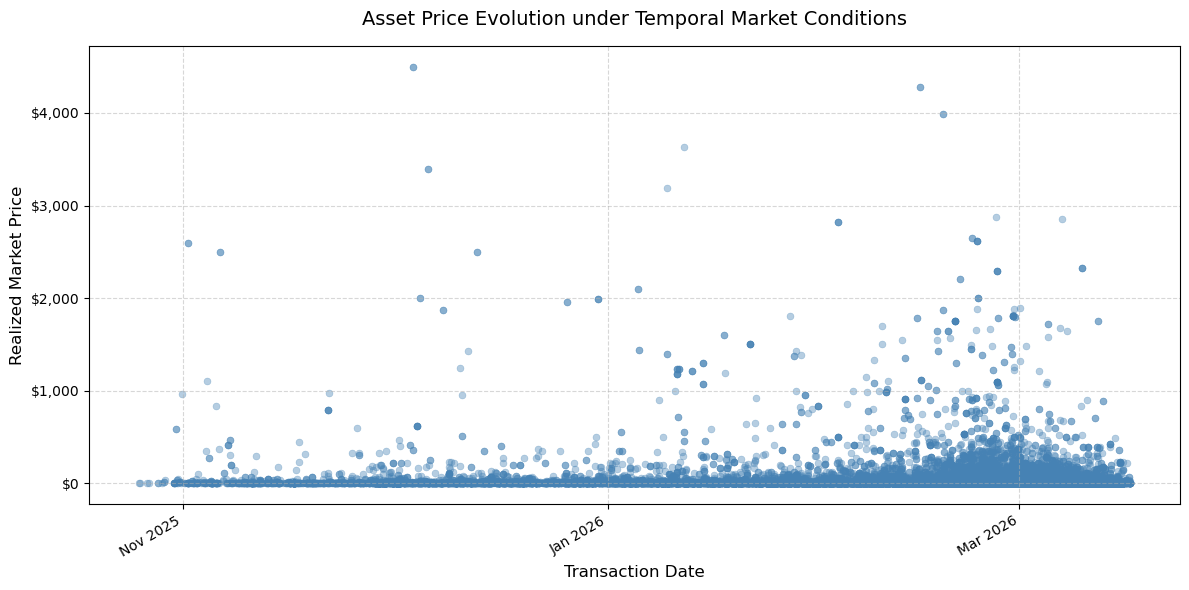

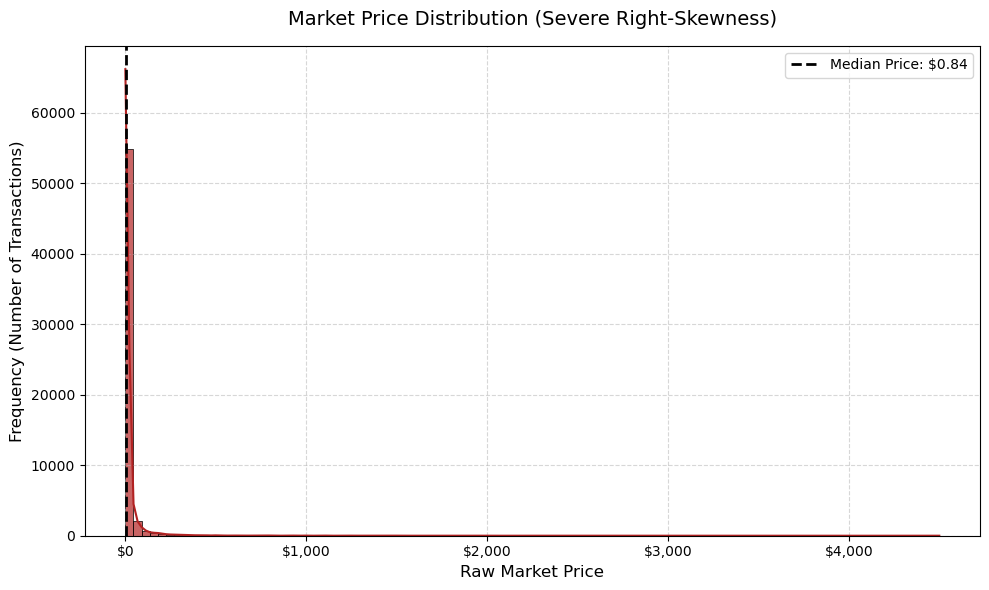

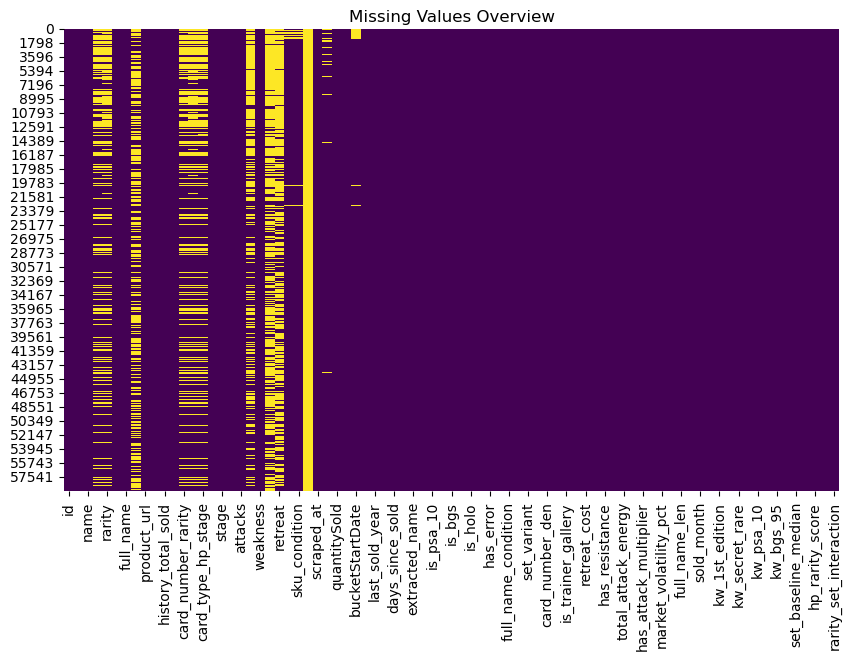

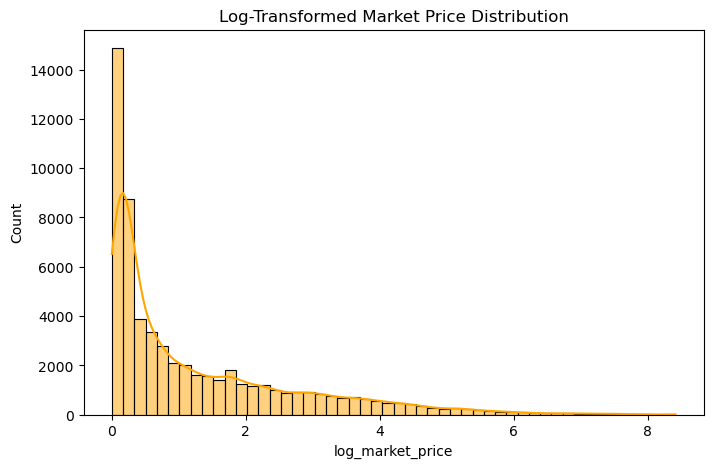

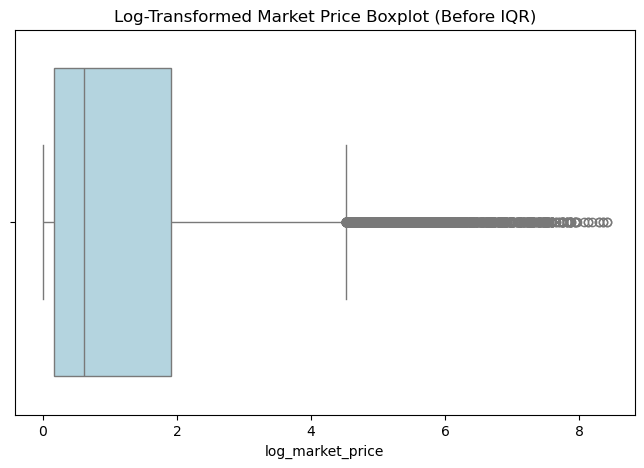

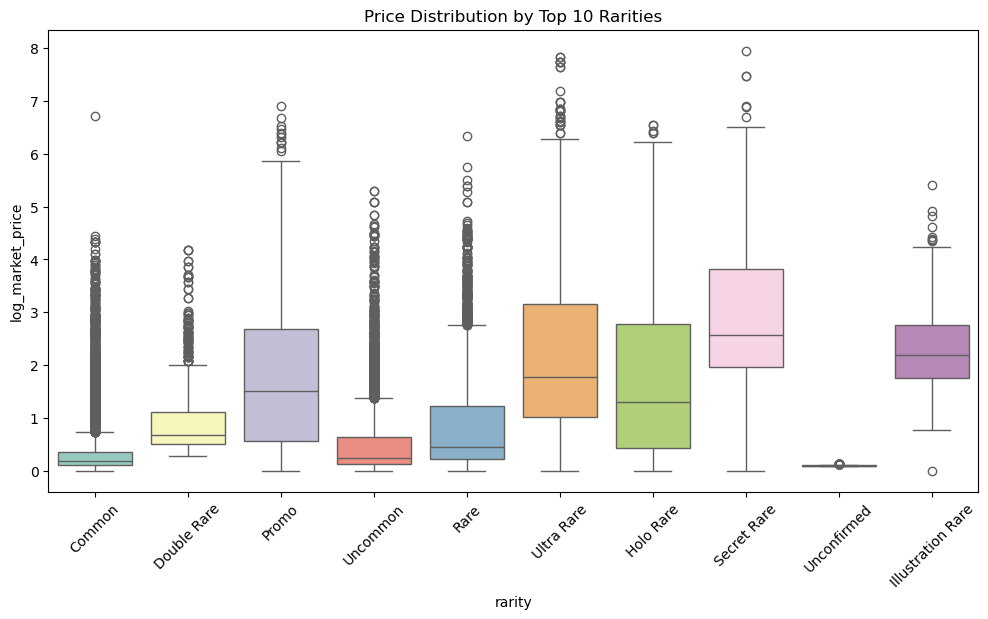

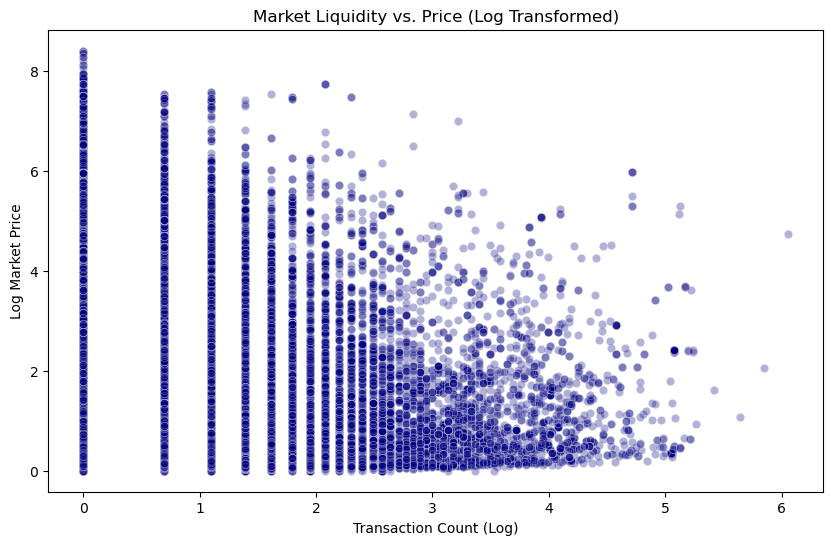

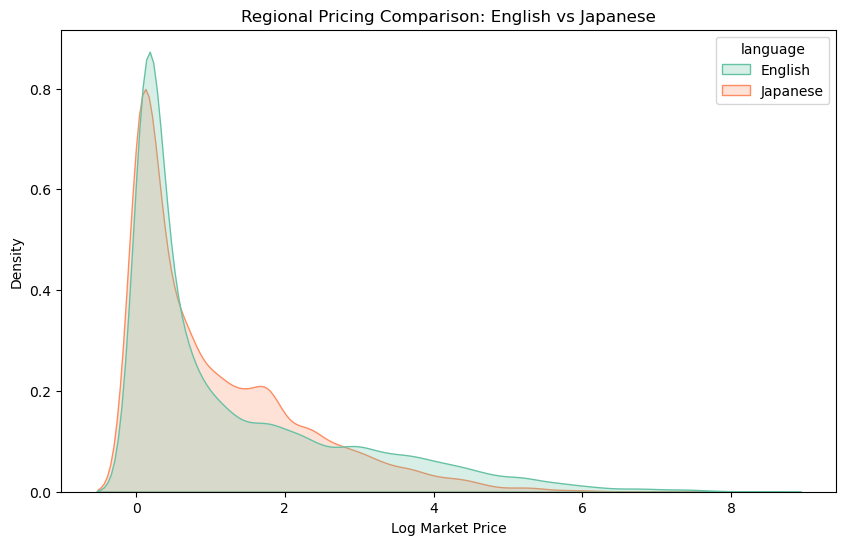

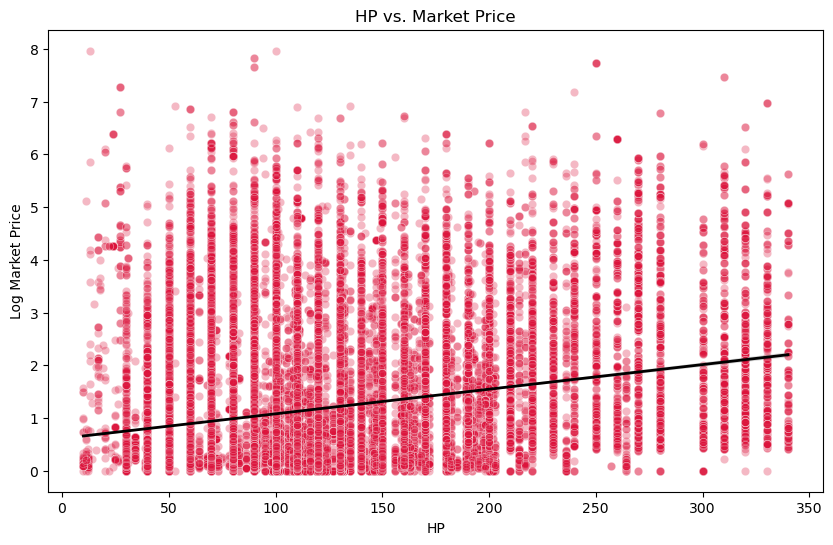

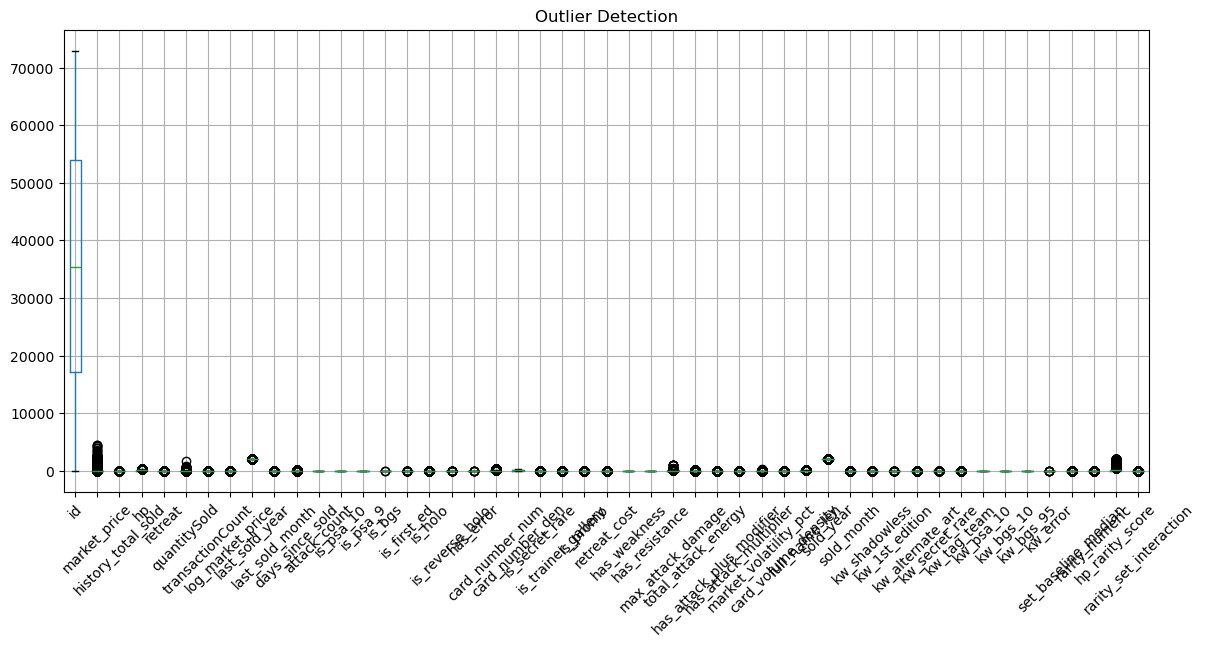

Removing extreme price outliers only
Dataset size after outlier removal from Target Variable: 59331 (Total removed Data Points: 0)


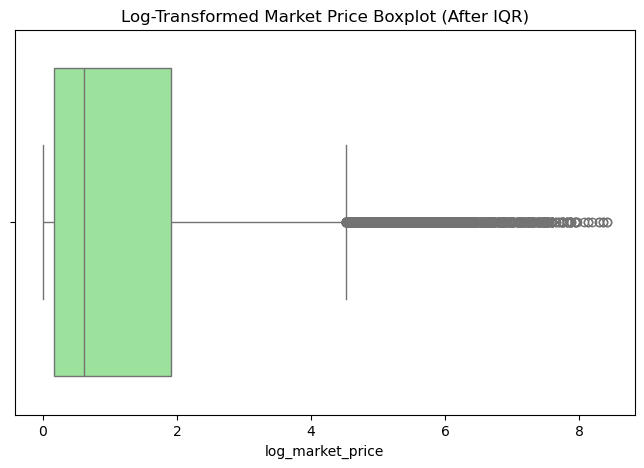

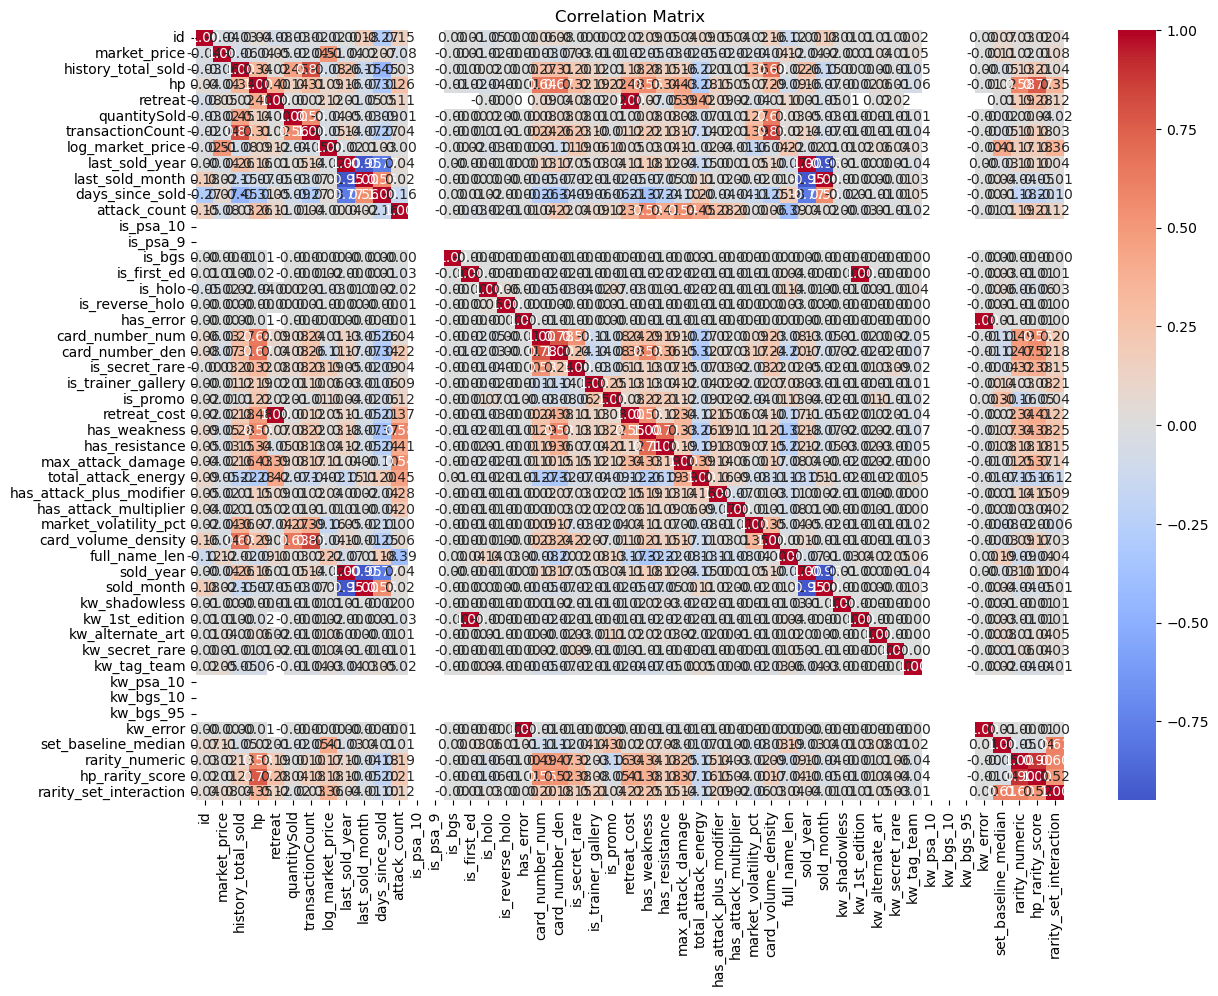

In [32]:
print("Generating EDA plots")
print("-" * 50)

plt.figure(figsize=(12, 6))

ax = sns.scatterplot(data=df, x="last_sold_date", y="market_price", 
                     alpha=0.4, color="steelblue", s=25, edgecolor=None)

plt.title("Asset Price Evolution under Temporal Market Conditions", fontsize=14, pad=15)
plt.xlabel("Transaction Date", fontsize=12)
plt.ylabel("Realized Market Price", fontsize=12)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate() # auto-rotates the dates so they don't overlap

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("figure_3_2_time_evolution.png", dpi=300) 
plt.show()


plt.figure(figsize=(10, 6))

ax = sns.histplot(df["market_price"].dropna(), bins=100, kde=True, 
                  color="firebrick", alpha=0.7, edgecolor="black")

median_val = df["market_price"].median()
plt.axvline(median_val, color='black', linestyle='dashed', linewidth=2, 
            label=f'Median Price: ${median_val:,.2f}')

plt.title("Market Price Distribution (Severe Right-Skewness)", fontsize=14, pad=15)
plt.xlabel("Raw Market Price", fontsize=12)
plt.ylabel("Frequency (Number of Transactions)", fontsize=12)


ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("figure_3_3_market_distribution.png", dpi=300)
plt.show()

# missing values overview
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Overview")
plt.show()

# target variable distribution (log-transformed)
plt.figure(figsize=(8, 5))
sns.histplot(df["log_market_price"], bins=50, kde=True, color="orange")
plt.title("Log-Transformed Market Price Distribution")
plt.show()

# outlier plot BEFORE IQR
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["log_market_price"], color="lightblue")
plt.title("Log-Transformed Market Price Boxplot (Before IQR)")
plt.show()

# 1. Price Distribution by Top Rarities
plt.figure(figsize=(12, 6))
top_rarities = df["rarity"].value_counts().nlargest(10).index
sns.boxplot(x="rarity", y="log_market_price", hue="rarity", data=df[df["rarity"].isin(top_rarities)], palette="Set3", legend=False)
plt.title("Price Distribution by Top 10 Rarities")
plt.xticks(rotation=45)
plt.show()

# 3. Market Liquidity vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x="transactionCount", y="log_market_price", data=df, alpha=0.3, color="navy")
plt.title("Market Liquidity vs. Price (Log Transformed)")
plt.xlabel("Transaction Count (Log)")
plt.ylabel("Log Market Price")
plt.show()

# 4. Regional Pricing Comparison
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="log_market_price", hue="language", fill=True, common_norm=False, palette="Set2")
plt.title("Regional Pricing Comparison: English vs Japanese")
plt.xlabel("Log Market Price")
plt.show()

# 5. HP vs. Market Price
plt.figure(figsize=(10, 6))
hp_filtered = df[df["hp"] > 0]
sns.scatterplot(x="hp", y="log_market_price", data=hp_filtered, alpha=0.3, color="crimson")
sns.regplot(x="hp", y="log_market_price", data=hp_filtered, scatter=False, color="black", line_kws={"linewidth":2})
plt.title("HP vs. Market Price")
plt.xlabel("HP")
plt.ylabel("Log Market Price")
plt.show()

# outlier plots
numeric_cols_to_filter = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(14, 6))
df[numeric_cols_to_filter].boxplot()
plt.title("Outlier Detection")
plt.xticks(rotation=45)
plt.show()

# removing outlier for market price (Target Variable)
print("Removing extreme price outliers only")
Q1 = df["log_market_price"].quantile(0.10)
Q3 = df["log_market_price"].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

initial_len = len(df)   
df = df[(df["log_market_price"] >= lower_bound) & (df["log_market_price"] <= upper_bound)]
print(f"Dataset size after outlier removal from Target Variable: {len(df)} (Total removed Data Points: {initial_len - len(df)})")

# outlier plot AFTER IQR
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["log_market_price"], color="lightgreen")
plt.title("Log-Transformed Market Price Boxplot (After IQR)")
plt.show()

# numeric feature correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


numeric_features = [
    'history_total_sold', 'transactionCount',
    'market_volatility_pct',
    'hp', 'max_attack_damage', 'days_since_sold', 'sold_year', 'sold_month',
    'attack_count', 'total_attack_energy', 'has_attack_plus_modifier', 'has_attack_multiplier'
]
numeric_features = [f for f in numeric_features if f in df.columns]

# impute native TCG gameplay attributes
for col in ['stage', 'card_type', 'weakness']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str)

# target Encoded for robustness
all_categorical_features = [
    'extracted_name', 'extracted_set', 'name_variant', 'set_variant', 'set_condition',
    'rarity', 'sku_condition', 'sku_variant', 'stage', 'card_type', 'weakness'
]

s_i = int(len(df) * 0.8)

# training partition only to avoid leakage
train_subset = df.iloc[:s_i]
set_medians = train_subset.groupby('extracted_set')['log_market_price'].median()

# fallback for Time Series Future Predict:
recent_modern_median = train_subset.iloc[int(len(train_subset)*0.9):]['log_market_price'].median()
df['set_baseline_median'] = df['extracted_set'].map(set_medians).fillna(recent_modern_median)

rarity_map = {'Common': 1, 'Uncommon': 2, 'Rare': 3, 'Holofoil Rare': 4, 'Ultra Rare': 5, 'Secret Rare': 6}
df['rarity_numeric'] = df['rarity'].map(rarity_map).fillna(1)
df['hp_rarity_score'] = df['hp'] * df['rarity_numeric']
df['set_condition'] = df['extracted_set'].astype(str) + "_" + df['sku_condition'].astype(str)
df['rarity_set_interaction'] = df['rarity_numeric'] * df['set_baseline_median']

# redefine features to include the new signals and grail matrix
structural_flags = ['is_secret_rare', 'is_trainer_gallery', 'is_promo', 'is_holo', 'is_reverse_holo', 'is_first_ed']
numeric_features += ['set_baseline_median', 'card_volume_density', 'full_name_len', 'rarity_set_interaction'] + grail_cols + structural_flags

X = df[list(dict.fromkeys(numeric_features + all_categorical_features + ['full_name']))]
y = df["log_market_price"]

X_train, X_test = X.iloc[:s_i].copy(), X.iloc[s_i:].copy()
y_train, y_test = y.iloc[:s_i].copy(), y.iloc[s_i:].copy()

master_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("targ", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), ("encoder", TargetEncoder(target_type="continuous", smooth=2.0, random_state=MASTER_SEED))]), all_categorical_features),
    ("text", Pipeline([("tfidf", TfidfVectorizer(max_features=4000, stop_words='english', ngram_range=(1, 3))), ("svd", TruncatedSVD(n_components=250, random_state=MASTER_SEED))]), "full_name")
])


---
## 6. Model Training: Deep Stacking Ensemble

The predictive modeling utilizes the Deep Stacking Ensemble (Wolpert, 1992). Deep Stacking trains a meta-learner using predictions from diverse base learners. The primary layer consists of a regularized linear model (Ridge) and powerful non-linear tree ensembles, including HistGradientBoosting (Ke et al., 2017), Random Forest (Breiman, 2001), and XGBoost (Chen & Guestrin, 2016).


Training Started
--------------------------------------------------

Model Performance Comparison (Train vs Test):
Training Deep_Stacking_Ensemble...

                 Model  Train_R2  Test_R2  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE
Deep_Stacking_Ensemble   0.95949 0.690208    0.301142   0.665659    0.19472  0.426317



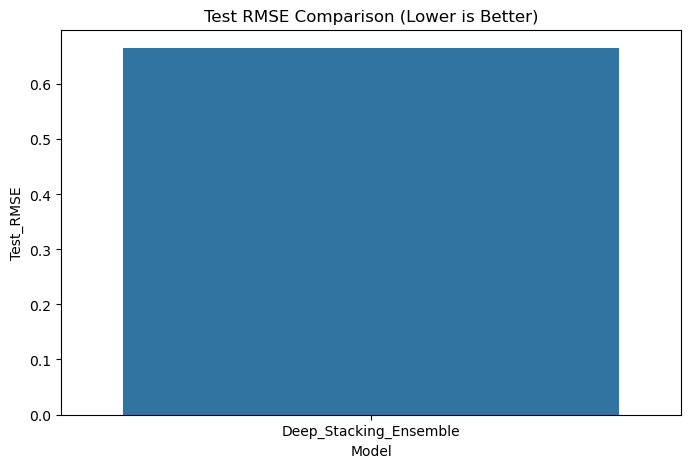

In [ ]:
print("\nTraining Started")
print("-" * 50)

from sklearn.linear_model import RidgeCV

# integrating a Linear Model (Ridge) into the Base Layer. 
base_estimators = [
    ('ridge_text', Ridge(alpha=10.0, random_state=MASTER_SEED)),
    ('hgb', HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, max_depth=15, l2_regularization=1.0, min_samples_leaf=15, random_state=MASTER_SEED)),
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, colsample_bytree=0.8, subsample=0.8, n_jobs=-1, random_state=MASTER_SEED)),
    ('rf', RandomForestRegressor(n_estimators=400, max_depth=25, min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=MASTER_SEED))
]
# deep stacking ensemble with a Linear Meta Learner (RidgeCV)
models = {
    "Deep_Stacking_Ensemble": (master_preprocessor, StackingRegressor(
        estimators=base_estimators,
        final_estimator=RidgeCV(),
        cv=KFold(n_splits=5, shuffle=True, random_state=MASTER_SEED),
        n_jobs=1  # Sequential to prevent memory crash
    ))
}

results = []
fitted_pipelines = {}

print("\nModel Performance Comparison (Train vs Test):")
for model_name, (preproc, model) in models.items():
    print(f"Training {model_name}...")
    pipeline = Pipeline([
        ("preprocessing", preproc),
        ("model", model)
    ])
        
    pipeline.fit(X_train, y_train)
    
    # Train Metrics
    train_preds = pipeline.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_mae = mean_absolute_error(y_train, train_preds)
    train_r2 = r2_score(y_train, train_preds)
    
    # Test Metrics
    test_preds = pipeline.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)
        
    results.append([model_name, train_r2, test_r2, train_rmse, test_rmse, train_mae, test_mae])
    fitted_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results, columns=[
    "Model", "Train_R2", "Test_R2", "Train_RMSE", "Test_RMSE", "Train_MAE", "Test_MAE"
])
print("\n" + "="*80)
print(results_df.to_string(index=False))
print("="*80 + "\n")

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Test_RMSE", data=results_df)
plt.title("Test RMSE Comparison (Lower is Better)")
plt.show()


---
## 7. Hyperparameter Optimization

To maximize the predictive efficiency of the ensemble framework, RandomizedSearchCV is used for automated hyperparameter optimization. RandomizedSearchCV converged to the optimal models more efficiently than grid searches in high-dimensional continuous domains (Bergstra and Bengio, 2012). Moreover, TimeSeriesSplit is employed to ensure the dataset's chronological integrity and to ensure the model is tuned strictly on historical data to predict the future.


Initializing Tuning Sequence for: Deep_Stacking_Ensemble
--------------------------------------------------
Launching Randomized Search Space...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV 1/3] END model__rf__max_depth=None, model__ridge_text__alpha=10.0, model__xgb__learning_rate=0.05, model__xgb__max_depth=8, preprocessing__targ__encoder__smooth=5.0, preprocessing__text__svd__n_components=100;, score=0.511 total time= 3.7min
[CV 2/3] END model__rf__max_depth=None, model__ridge_text__alpha=10.0, model__xgb__learning_rate=0.05, model__xgb__max_depth=8, preprocessing__targ__encoder__smooth=5.0, preprocessing__text__svd__n_components=100;, score=0.712 total time= 5.0min
[CV 3/3] END model__rf__max_depth=None, model__ridge_text__alpha=10.0, model__xgb__learning_rate=0.05, model__xgb__max_depth=8, preprocessing__targ__encoder__smooth=5.0, preprocessing__text__svd__n_components=100;, score=0.723 total time= 6.7min
[CV 1/3] END model__rf__max_depth=30, model__ridge_tex

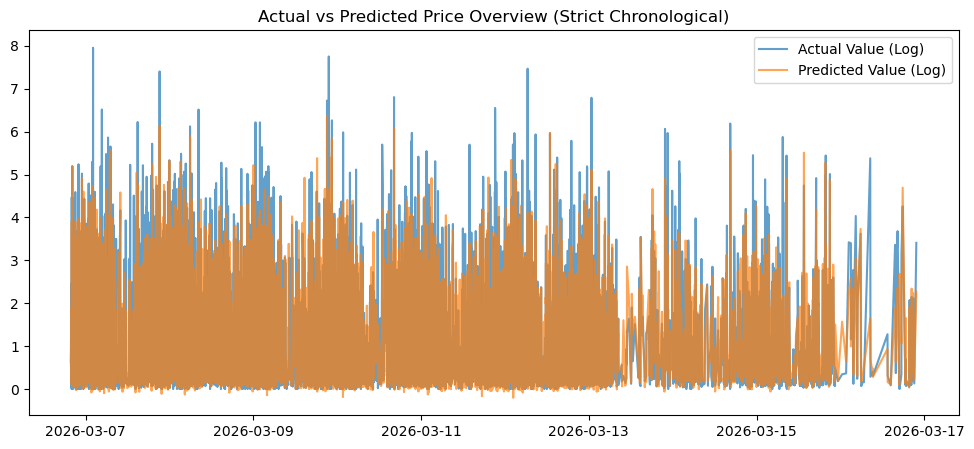

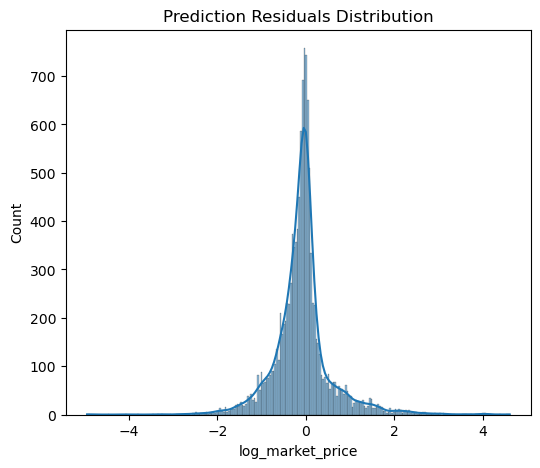

In [ ]:
best_model_name = results_df.loc[results_df['Test_RMSE'].idxmin(), 'Model']
print(f"\nInitializing Tuning Sequence for: {best_model_name}")
print('-' * 50)

best_pipeline_preproc, best_model_instance = models[best_model_name]
base_pipeline = Pipeline([
    ("preprocessing", best_pipeline_preproc),
    ("model", best_model_instance)
])

# pipeline tuning matrix
param_grids = {
    "Deep_Stacking_Ensemble": {
        'preprocessing__text__svd__n_components': [100, 200, 300],
        'preprocessing__targ__encoder__smooth': [1.0, 2.0, 5.0],
        'model__ridge_text__alpha': [1.0, 10.0, 100.0],
        'model__xgb__max_depth': [6, 8, 12],
        'model__xgb__learning_rate': [0.03, 0.05],
        'model__rf__max_depth': [20, 30, None]
    }
}

print("Launching Randomized Search Space...")
tscv = TimeSeriesSplit(n_splits=3)
random_search = RandomizedSearchCV(
    base_pipeline, 
    param_distributions=param_grids[best_model_name], 
    n_iter=40,
    cv=tscv, 
    scoring='r2',
    n_jobs=1,
    verbose=3,
    random_state=MASTER_SEED
)
# fitting the Randomized Search with TimeSeriesSplit to prevent any look-ahead bias.
random_search.fit(X_train, y_train)
# best performers from the Randomized Search
final_pipeline = random_search.best_estimator_
# evaluate the final tuned model on the test set
final_preds = final_pipeline.predict(X_test)
# calculating R2 Score for the final tuned model
r2_final = r2_score(y_test, final_preds)
print(f"\nFinal Tuned Model R2 Score: {r2_final:.4f}")
best_model_name = results_df.loc[results_df['Test_RMSE'].idxmin(), 'Model']
final_pipeline = fitted_pipelines[best_model_name]
final_preds = final_pipeline.predict(X_test)

# Visualizing Actual vs Predicted Values in Strict Chronological Order
plt.figure(figsize=(12, 5))
plt.plot(df["last_sold_date"].iloc[s_i:], y_test, label="Actual Value (Log)", alpha=0.7)
plt.plot(df["last_sold_date"].iloc[s_i:], final_preds, label="Predicted Value (Log)", alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted Price Overview (Strict Chronological)")
plt.show()

residuals = y_test - final_preds
plt.figure(figsize=(6, 5))
sns.histplot(residuals, kde=True)
plt.title("Prediction Residuals Distribution")
plt.show()

---
## 8. Permutation Analysis

Permutation Feature Importance was applied to assess the importance of each feature. Originally developed for Random Forests (Breiman, 2001) and suitable for all models. Permutation Importance measures the intrinsic influence of each feature by randomly permuting its values. The decrease in performance indicates the actual importance of the features in model predictions.


Permutation Analysis
--------------------------------------------------


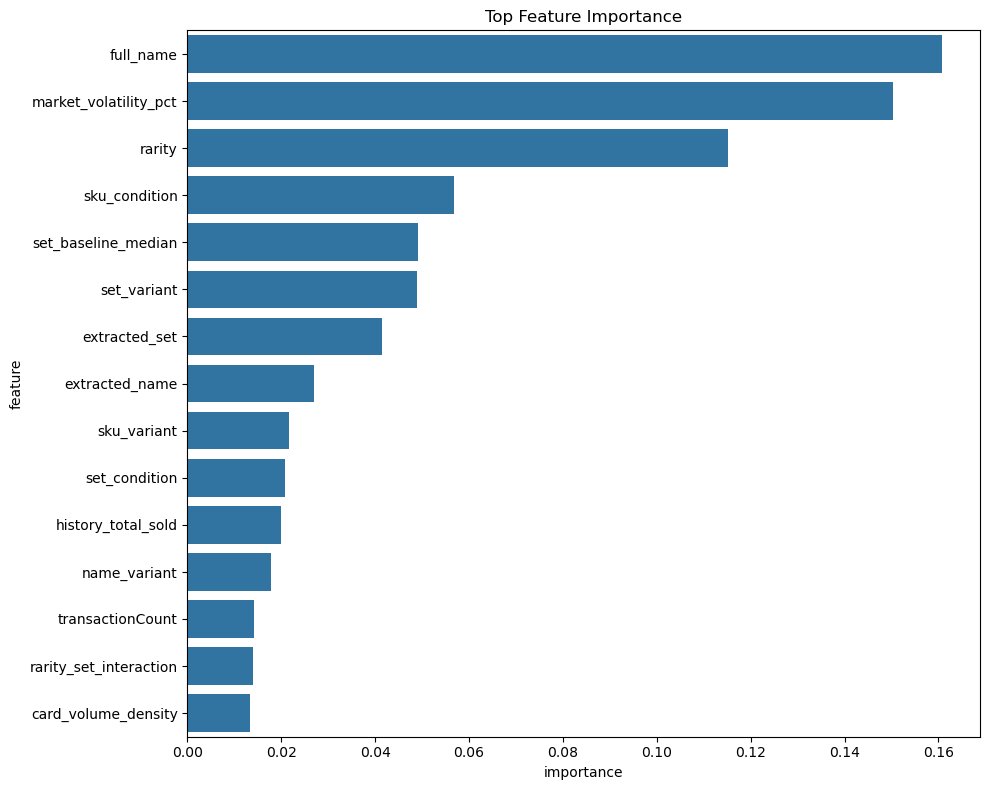

In [ ]:
print("\nPermutation Analysis")
print("-" * 50)
result = permutation_importance(
    final_pipeline, X_test, y_test, n_repeats=5, random_state=MASTER_SEED, n_jobs=1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns, 
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=importance_df.head(15))
plt.title("Top Feature Importance")
plt.tight_layout()
plt.show()

---
## 8. Advanced Diagnostic Plots

This block generates three advanced diagnostic visualizations on the unseen test data.


Generating Advanced Diagnostic Plots
--------------------------------------------------


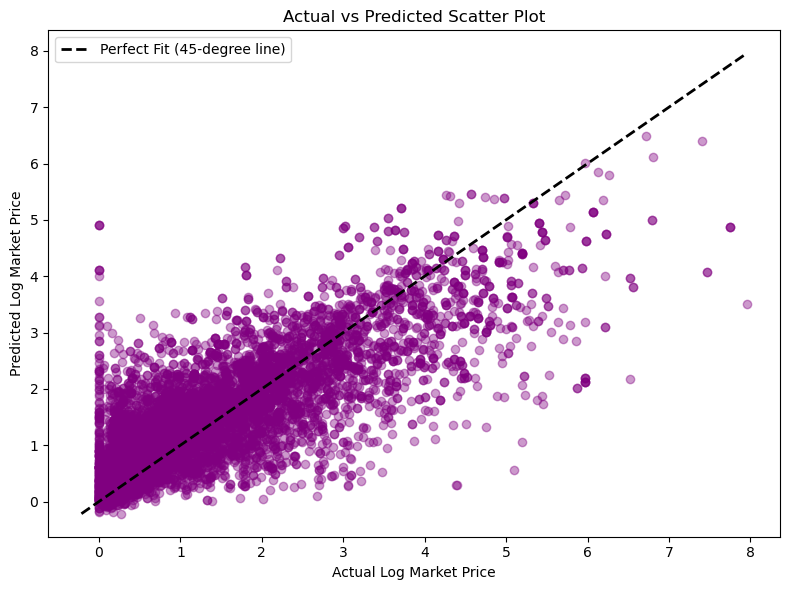

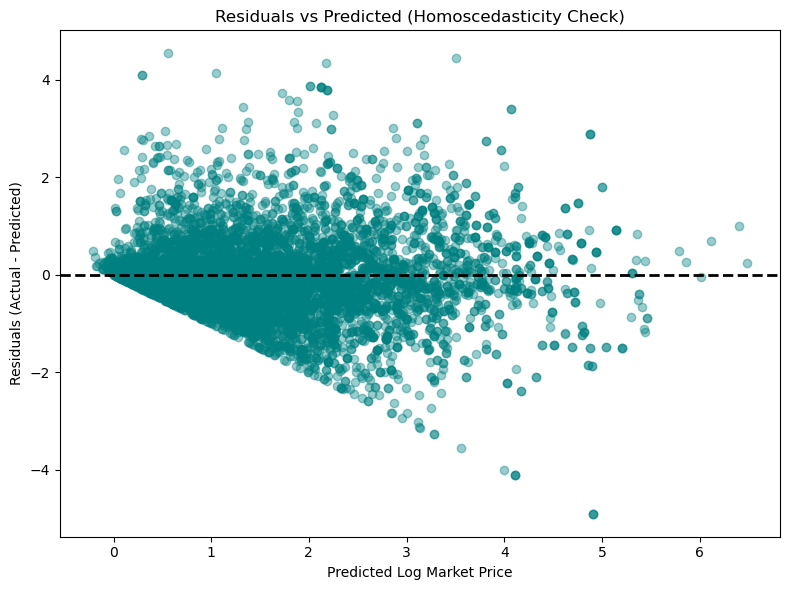

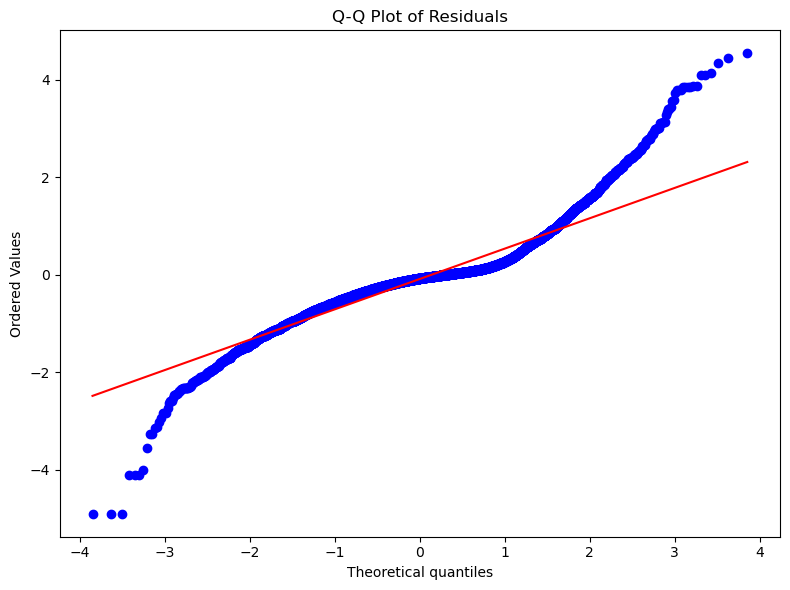

In [ ]:
print("\nGenerating Advanced Diagnostic Plots")
print("-" * 50)

#  Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, alpha=0.4, color="purple")
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect Fit (45-degree line)")
plt.xlabel("Actual Log Market Price")
plt.ylabel("Predicted Log Market Price")
plt.title("Actual vs Predicted Scatter Plot")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - test_preds

#  Residuals vs Predicted (Funnel Check)
plt.figure(figsize=(8, 6))
plt.scatter(test_preds, residuals, alpha=0.4, color="teal")
plt.axhline(0, color="black", linestyle="--", lw=2)
plt.xlabel("Predicted Log Market Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted (Homoscedasticity Check)")
plt.tight_layout()
plt.show()

# Q-Q Plot of Residuals
import scipy.stats as stats
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

---
### References
Belsley, D. A., Kuh, E., & Welsch, R. E. (2005). Regression diagnostics: Identifying influential data and sources of collinearity. John Wiley & Sons.

Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. Journal of machine learning research, 13(2).

Breiman, L. (2001). Random forests. Machine learning, 45(1), 5–32.

Chen, T., & Guestrin, C. (2016). Xgboost: A scalable tree boosting system. Proceedings of the 22nd acm sigkdd international conference on knowledge discovery and data mining, 785–794.

Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., & Harshman, R. (1990). Indexing by latent semantic analysis. Journal of the American society for information science, 41(6), 391–407.

Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. ACM Transactions on Knowledge Discovery from Data (TKDD), 6(4), 1–21.

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). Lightgbm: A highly efficient gradient boosting decision tree. Advances in neural information processing systems, 30.

Little, R. J. A., & Rubin, D. B. (2019). Statistical analysis with missing data. John Wiley & Sons.

Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems. ACM SIGKDD explorations newsletter, 3(1), 27–32.

Parzen, E. (1962). On estimation of a probability density function and mode. The annals of mathematical statistics, 33(3), 1065–1076.

Pineau, J., Vincent-Lamarre, P., Sinha, K., Larivière, V., Beygelzimer, A., d'Alché-Buc, F., Fox, E., & Larochelle, H. (2021). Improving reproducibility in machine learning research (a report from the neurips 2019 reproducibility program). Journal of machine learning research, 22(164), 1–20.

Tukey, J. W., et al. (1977). Exploratory data analysis (Vol. 2). Springer.

Wolpert, D. H. (1992). Stacked generalization. Neural networks, 5(2), 241–259.

Wooldridge, J. M. (2016). Introductory econometrics a modern approach. South-Western cengage learning.